In [21]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from mp_api.client import MPRester
from pymatgen.core.structure import Structure
api_key = "fzkCeUsip3BWLqWADKl4e3lOWKwup3it"   
mpr = MPRester(api_key)


In [22]:
fields = [
    "material_id",
    "formula_pretty",
    "band_gap",                       # fino a qui non usare come feature
    "formation_energy_per_atom",
    "energy_above_hull",
    "density",
    "volume",
    "nsites",
    "symmetry",                       
    "efermi",
    "total_magnetization",
    "total_magnetization_normalized_vol",
    "num_magnetic_sites"
]

In [23]:
docs = []
with MPRester(api_key) as mpr:
    # filtro: solo binari (nelements=2). Otteniamo tutti i doc summary con i campi richiesti.
    docs = mpr.materials.summary.search(nelements=2, fields=fields)

print(f"Docs fetched: {len(docs)}")

/home/utente/Data_Science/mp_env/lib/python3.11/site-packages/mp_api/client/routes/materials/summary.py:278: MPRestWarning: You have specified fields used by `_search` that can be understood by `search`
   nelements
To ensure long term support, please use their `search` equivalents:
   num_elements
Please see the documentation:
    `search`: https://materialsproject.github.io/api/_autosummary/mp_api.client.routes.materials.summary.SummaryRester.html#mp_api.client.routes.materials.summary.SummaryRester.search
   `_search`: https://api.materialsproject.org/redoc#tag/Materials-Summary/operation/search_materials_summary__get
  warnings.warn(


Retrieving SummaryDoc documents:   0%|          | 0/20765 [00:00<?, ?it/s]

Docs fetched: 20765


In [24]:
X = []
y = [] #il nostro target è l'energy gap
for d in docs:
    features = np.array([
        d.formation_energy_per_atom or 0.0,
        d.energy_above_hull or 0.0,
        d.density or 0.0,
        d.volume or 0.0,
        d.nsites or 0.0,
        d.symmetry.number if d.symmetry is not None else 0.0,
        d.efermi or 0.0,
        d.total_magnetization or 0.0,
        d.total_magnetization_normalized_vol or 0.0,
        d.num_magnetic_sites or 0.0
    ])
    X.append(features)
    y.append(d.band_gap)  # band gap come target

In [25]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20765, 10)
y shape: (20765,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)



In [27]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lin = lr.predict(X_test_s)

r2 = r2_score(y_test, y_pred_lin)

mse = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse)

print("LINEAR REGRESSION:")
print("RMSE =", rmse_lin)
print("R2   =", r2)

LINEAR REGRESSION:
RMSE = 0.848857080833675
R2   = 0.43513232418148706


In [28]:
#correlazione
corr = np.zeros(10)
for j in range(10):
    corr[j] = np.corrcoef(X[:, j], y)[0, 1]

print("Correlazioni feature → band gap:")
for i, r in enumerate(corr):
    print(f"{fields[i+3]}: r = {r:.3f}")

Correlazioni feature → band gap:
formation_energy_per_atom: r = -0.556
energy_above_hull: r = -0.089
density: r = -0.298
volume: r = 0.180
nsites: r = 0.265
symmetry: r = -0.170
efermi: r = -0.440
total_magnetization: r = -0.057
total_magnetization_normalized_vol: r = -0.105
num_magnetic_sites: r = -0.078


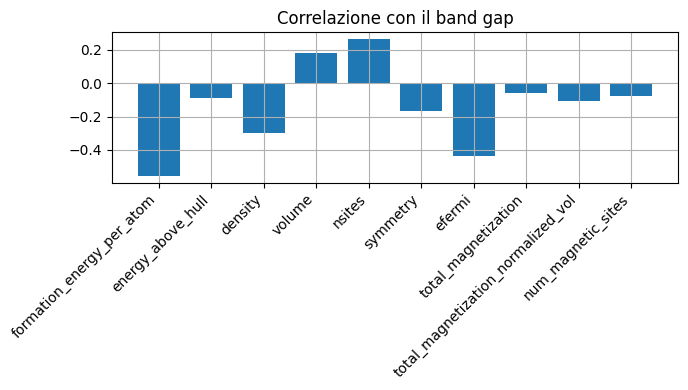

In [29]:
plt.figure(figsize=(7,4))
plt.grid(True)
plt.bar(range(10), corr)
plt.xticks(range(10), fields[3:], rotation=45, ha='right')
plt.title("Correlazione con il band gap")
plt.tight_layout()
plt.show()

In [30]:
coefs_lin = lr.coef_
print("Coefficienti Linear Regression: ", coefs_lin)

Coefficienti Linear Regression:  [-0.58039446  0.09717465 -0.04841551 -0.11921203  0.2222808   0.02671513
 -0.35118655  0.02854885 -0.03870888 -0.17058486]


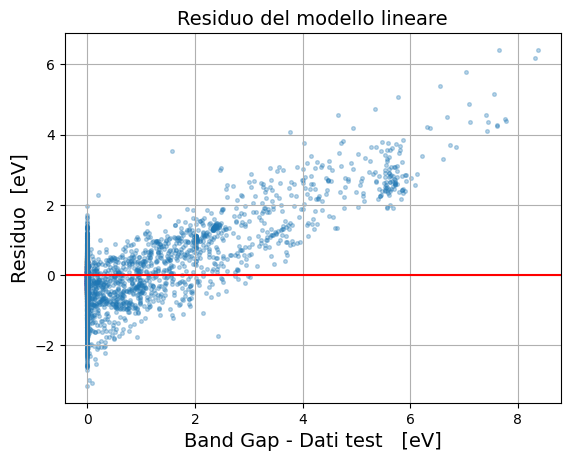

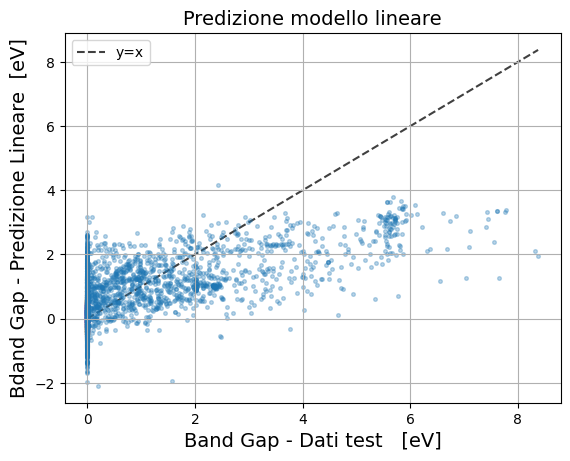

In [31]:
residuals_lin = y_test - y_pred_lin

plt.scatter(y_test, residuals_lin, alpha=0.3, s=7)
plt.axhline(0, color='red')
plt.xlabel("Band Gap - Dati test   [eV]", fontsize=14)
plt.ylabel("Residuo  [eV]", fontsize=14)
plt.grid(True)
plt.title("Residuo del modello lineare", fontsize=14)
plt.show()


plt.scatter(y_test, y_pred_lin, alpha=0.3, s=7)
plt.xlabel("Band Gap - Dati test   [eV]", fontsize=14)
plt.ylabel("Bdand Gap - Predizione Lineare  [eV]", fontsize=14)
plt.grid(True)
plt.title("Predizione modello lineare", fontsize=14)
#retta a 45 gradi
lims = [0, max(max(y_test), max(y_pred_lin))]
plt.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='y=x')
plt.legend()
plt.show()



In [32]:
alphas = np.logspace(-3, 8, 100)
ridge=linear_model.Ridge()
lasso = linear_model.Lasso()

coefs_ridge = []
coefs_lasso=[]

r2_train_ridge = []
r2_test_ridge = []

r2_train_lasso = []
r2_test_lasso = []

for a in alphas:
    ridge.set_params(alpha=a)
    ridge.fit(X_train_s, y_train)
    coefs_ridge.append(ridge.coef_)
    
    # Use the coefficient of determination R^2 as the performance of prediction.
    r2_train_ridge.append(ridge.score(X_train_s, y_train))
    r2_test_ridge.append(ridge.score(X_test_s, y_test))
    
    lasso.set_params(alpha=a)
    lasso.fit(X_train_s, y_train)
    coefs_lasso.append(lasso.coef_)
    
    # Use the coefficient of determination R^2 as the performance of prediction.
    r2_train_lasso.append(lasso.score(X_train_s, y_train))
    r2_test_lasso.append(lasso.score(X_test_s, y_test))

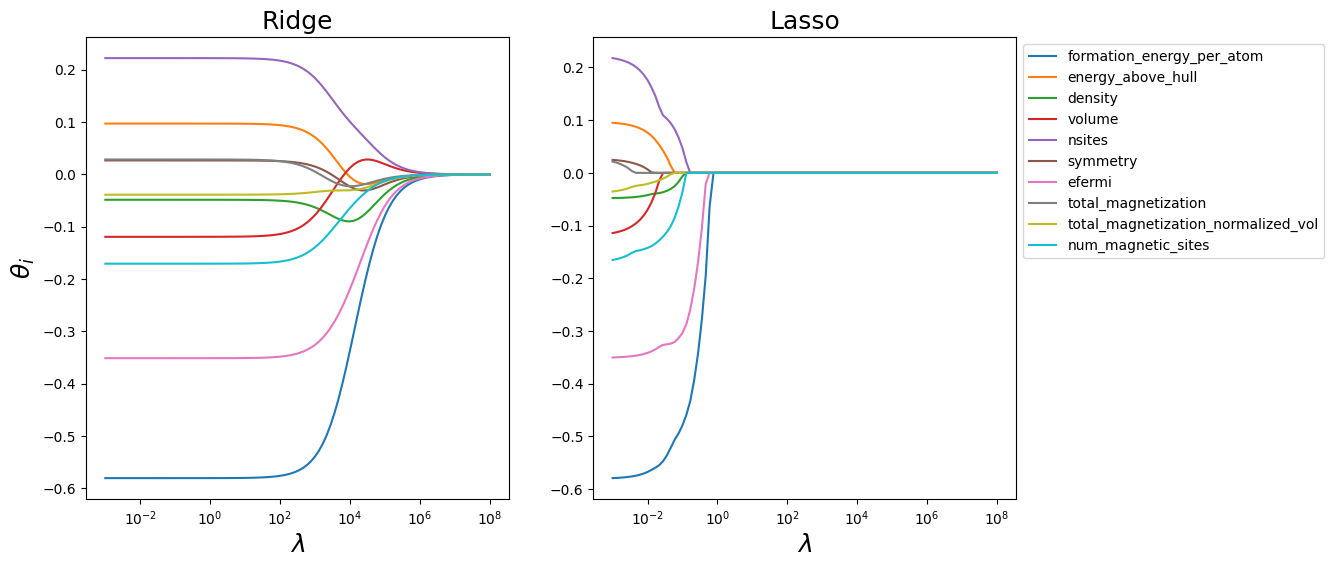

In [33]:
#Vediamo le 100 feature che abbiamo imparato mentre cambiamo il parametro di regolarizzazione
fig, ax = plt.subplots(1,2, figsize=(12,6))


plt.subplot(1,2,1)
plt.semilogx(alphas, coefs_ridge)
axes = plt.gca()
plt.xlabel(r'$\lambda$',fontsize=18)
plt.ylabel(r'$\theta_i$',fontsize=18)
plt.title('Ridge', fontsize=18)

plt.subplot(1,2,2)
plt.semilogx(alphas, coefs_lasso)
axes = plt.gca()
plt.xlabel(r'$\lambda$',fontsize=18)
plt.title('Lasso', fontsize=18)

plt.legend(fields[3:], loc='upper left', bbox_to_anchor=(1,1))
plt.show()

In [34]:
#Ridge
alpha_ridge = 2000
# Predizione e calcolo metriche
ridge.set_params(alpha=alpha_ridge  )
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"\n--- RIDGE con labda={alpha_ridge} ---")
print(f"RMSE (Ridge): {rmse_ridge:.4f}")
print(f"R² (Ridge):   {r2_ridge:.4f}")

#Lasso
alpha_lasso = 0.02
# Predizione e calcolo metriche
lasso.set_params(alpha=alpha_lasso  )
lasso.fit(X_train_s, y_train)
y_pred_lasso = lasso.predict(X_test_s)
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print(f"\n--- RIDGE con labda={alpha_lasso} ---")
print(f"RMSE (Lasso): {rmse_lasso:.4f}")
print(f"R² (Lasso):   {r2_lasso:.4f}")


--- RIDGE con labda=2000 ---
RMSE (Ridge): 0.8521
R² (Ridge):   0.4308

--- RIDGE con labda=0.02 ---
RMSE (Lasso): 0.8514
R² (Lasso):   0.4317


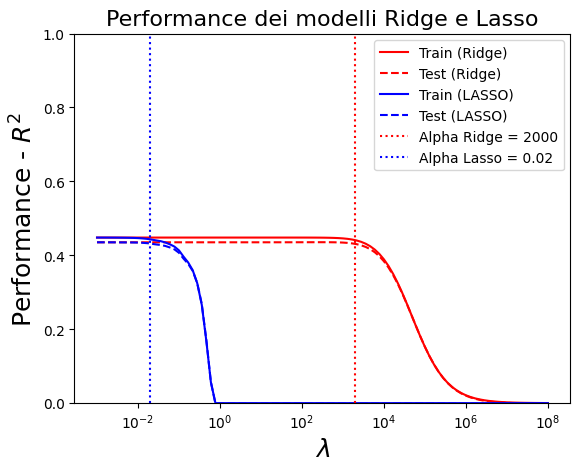

In [35]:
fig, ax = plt.subplots()

plt.semilogx(alphas, r2_train_ridge, 'r',label='Train (Ridge)')
plt.semilogx(alphas, r2_test_ridge, '--r',label='Test (Ridge)')
plt.semilogx(alphas, r2_train_lasso, 'b',label='Train (LASSO)')
plt.semilogx(alphas, r2_test_lasso, '--b',label='Test (LASSO)')

plt.ylim([0.0, 1.0])
plt.xlabel(r'$\lambda$',fontsize=18)
plt.ylabel('Performance - $R^2$',fontsize=18)
#aggiungo linne verticali per i migliori alpha
plt.axvline(alpha_ridge, color='r', linestyle=':', label=f'Alpha Ridge = {alpha_ridge}')
plt.axvline(alpha_lasso, color='b', linestyle=':', label=f'Alpha Lasso = {alpha_lasso}')
plt.title('Performance dei modelli Ridge e Lasso', fontsize=16)
plt.legend(loc='upper right')
plt.show()

In [36]:
degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=True)

X_train_p = poly.fit_transform(X_train_s)
X_test_p = poly.transform(X_test_s)

lr_poly = LinearRegression().fit(X_train_p, y_train)
y_pred_poly = lr_poly.predict(X_test_p)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
print("RMSE Polynomial:", rmse_poly)

RMSE Polynomial: 0.6857543463733144


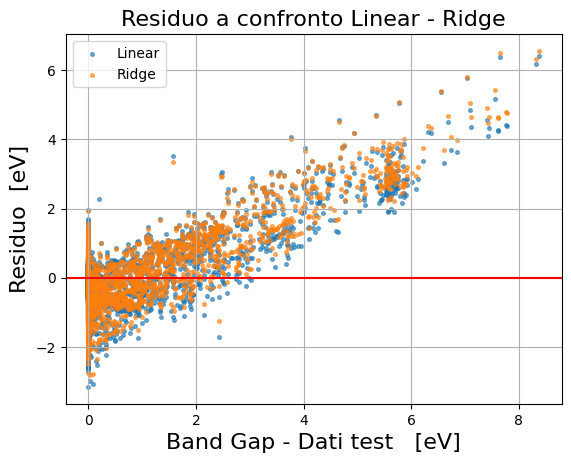

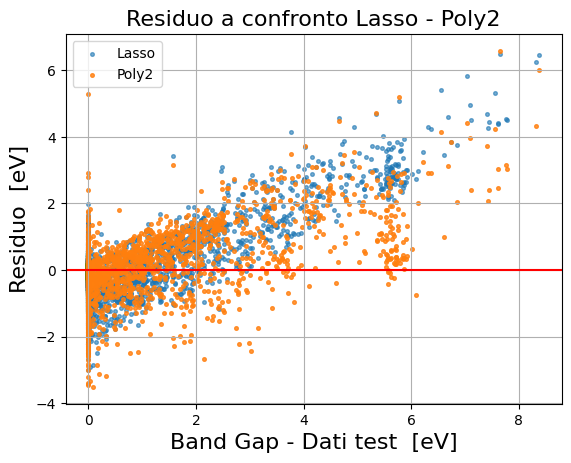

In [37]:
residuals_ridge =  y_test - y_pred_ridge
residuals_lasso = y_test - y_pred_lasso
residuals_poly = y_test - y_pred_poly

plt.scatter(y_test, residuals_lin, alpha=0.6, s=7,label='Linear')
plt.scatter(y_test, residuals_ridge, alpha=0.6, s=7,label='Ridge')
plt.axhline(0, color='red')
plt.xlabel("Band Gap - Dati test   [eV]", fontsize=16)
plt.ylabel("Residuo  [eV]", fontsize=16)
plt.grid(True)
plt.legend()
plt.title("Residuo a confronto Linear - Ridge", fontsize=16)
plt.show()

plt.scatter(y_test, residuals_lasso, alpha=0.6, s=7,label='Lasso')
plt.scatter(y_test, residuals_poly, alpha=0.8, s=7, label=f'Poly{degree}')
plt.axhline(0, color='red')
plt.xlabel("Band Gap - Dati test  [eV]", fontsize=16)
plt.ylabel("Residuo  [eV]", fontsize=16)
plt.grid(True)
plt.legend()
plt.title(f"Residuo a confronto Lasso - Poly{degree}", fontsize=16)
plt.show()

In [38]:
#tabella finale con i confronti linear, ridge e lasso ottimali e poly
print("\n--- RIEPILOGO METRICHE ---")
print(f"{'Modello':<15} {'RMSE':<15} {'R²':<15}")
print(f"{'-'*45}")
print(f"{'Linear':<15} {rmse_lin:<15.4f} {r2:<15.4f}")
print(f"{'Ridge ':<15} {rmse_ridge:<15.4f} {r2_ridge:<15.4f}")
print(f"{'Lasso ':<15} {rmse_lasso:<15.4f} {r2_lasso:<15.4f}")
print(f"{f'Poly (deg={degree})':<15} {rmse_poly:<15.4f} {r2_score(y_test, y_pred_poly):<15.4f}")


--- RIEPILOGO METRICHE ---
Modello         RMSE            R²             
---------------------------------------------
Linear          0.8489          0.4351         
Ridge           0.8521          0.4308         
Lasso           0.8514          0.4317         
Poly (deg=2)    0.6858          0.6313         
